In [58]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from datetime import datetime, timedelta

import matplotlib.pyplot as plt


import seaborn as sns

# Data source (common choice). Install: pip install yfinance
import yfinance as yf

# ML regression method (curve approximation of frontier)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [59]:
@dataclass
class PortfolioResult:
    weights: np.ndarray
    exp_return: float
    exp_vol: float
    sharpe: float


In [ ]:


class EfficientFrontierProject:
    """
    Builds an Efficient Frontier using:
      (1) Monte Carlo simulation of random portfolios
      (2) A regression-based learned frontier from the simulated results

    Outputs:
      - correlation matrix heatmap
      - scatter plot of portfolios (risk vs return) + max Sharpe + min vol markers
      - regression frontier curve
      - optimal max-Sharpe weights
      - optimal min-volatility weights
      - saved files
    """

    def __init__(self, tickers, years=2, rf_annual=0.03, trading_days=252, seed=42):
        self.tickers = tickers
        self.years = years
        self.rf_annual = rf_annual
        self.trading_days = trading_days
        self.seed = seed

        self.prices = None
        self.returns_daily = None

        self.mu_annual = None
        self.cov_annual = None
        self.corr = None

        self.sim_df = None
        self.max_sharpe_row = None
        self.min_vol_row = None

    def fetch_prices(self, price_field="Close"):
        """
        Retrieve daily data for previous 2 years.
        """
        end = datetime.today()
        start = end - timedelta(days=int(self.years * 365.25))

        df = yf.download(self.tickers, start=start.strftime("%Y-%m-%d"), end=end.strftime("%Y-%m-%d"))
        if isinstance(df.columns, pd.MultiIndex):
            # yfinance returns multiindex columns if multiple tickers
            if price_field not in df.columns.levels[0]:
                raise ValueError(f"Price field '{price_field}' not found. Available: {df.columns.levels[0]}")
            prices = df[price_field].copy()
        else:
            # single ticker case
            prices = df[[price_field]].copy()
            prices.columns = self.tickers

        prices = prices.dropna(how="all").dropna(axis=1)  # drop any tickers that failed
        if prices.shape[1] != len(self.tickers):
            missing = set(self.tickers) - set(prices.columns)
            raise ValueError(f"Missing tickers data: {missing}")

        self.prices = prices
        return self.prices

    def compute_inputs(self):
        """
        mean, variance, correlation matrix
        Using log returns (common in finance).
        """
        if self.prices is None:
            raise RuntimeError("Run fetch_prices() first.")

        # daily log returns
        self.returns_daily = np.log(self.prices / self.prices.shift(1)).dropna()

        # annualized expected return (mean) and covariance
        mu_daily = self.returns_daily.mean()
        cov_daily = self.returns_daily.cov()

        self.mu_annual = mu_daily * self.trading_days
        self.cov_annual = cov_daily * self.trading_days
        # create a matrix like [corr(JPM, KO), corr(JPM, XOM), corr(KO,XOM)]
        self.corr = self.returns_daily.corr()

        return self.mu_annual, self.cov_annual, self.corr

    def _portfolio_stats(self, weights):
        """
        Expected annual return, annual volatility, Sharpe ratio
        """

        # sum_(1,n){(w_i*mu_i)}
        exp_return = float(np.dot(weights, self.mu_annual.values))

        # self.cov_annual.values is ucase(sigma) in the notation
        exp_var = float(weights.T @ self.cov_annual.values @ weights)
        exp_vol = float(np.sqrt(exp_var))

        sharpe = (exp_return - self.rf_annual) / exp_vol if exp_vol > 0 else -np.inf
        return exp_return, exp_vol, sharpe # expected return, expected volatility, and sharpe

    # add portfolio weights through monte carlo method
    def run_monte_carlo(self, n_portfolios=50_000):
        """
        (Monte Carlo): generate random weights, compute stats.
        """
        if self.mu_annual is None:
            raise RuntimeError("Run compute_inputs() first.")

        rng = np.random.default_rng(self.seed)
        k = len(self.tickers)

        results = []
        for _ in range(n_portfolios):
            w = rng.random(k)
            w = w / w.sum()
            r, v, s = self._portfolio_stats(w)
            results.append((v, r, s, *w))

        cols = ["vol", "ret", "sharpe"] + [f"w_{t}" for t in self.tickers]
        self.sim_df = pd.DataFrame(results, columns=cols)

        # Identify optimum Sharpe and minimum volatility portfolios
        self.max_sharpe_row = self.sim_df.iloc[self.sim_df["sharpe"].idxmax()]
        self.min_vol_row = self.sim_df.iloc[self.sim_df["vol"].idxmin()]

        return self.sim_df


    def fit_regression_frontier(self, n_bins=60, poly_degree=3):
        """
        (Regression/ML):
          - Bin vol (risk) axis
          - In each bin, pick the portfolio with maximum return (efficient set)
          - Fit a polynomial regression: return ~ f(vol)

        This is a "machine learning regression" method that learns the frontier curve
        from the Monte Carlo cloud.
        """
        if self.sim_df is None:
            raise RuntimeError("Run run_monte_carlo() first.")

        df = self.sim_df.copy()

        # Bin by volatility
        df["bin"] = pd.cut(df["vol"], bins=n_bins, labels=False)

        # In each bin, keep the max return portfolio (upper envelope)
        frontier_pts = (
            df.dropna(subset=["bin"])
              .sort_values(["bin", "ret"], ascending=[True, False])
              .groupby("bin", as_index=False)
              .head(1)
              .sort_values("vol")
        )

        X = frontier_pts[["vol"]].values
        y = frontier_pts["ret"].values

        poly = PolynomialFeatures(degree=poly_degree, include_bias=False)
        Xp = poly.fit_transform(X)

        model = LinearRegression()
        model.fit(Xp, y)

        # Create smooth curve across vol range
        vol_grid = np.linspace(df["vol"].min(), df["vol"].max(), 300).reshape(-1, 1)
        vol_grid_p = poly.transform(vol_grid)
        ret_pred = model.predict(vol_grid_p)

        return frontier_pts, vol_grid.flatten(), ret_pred, model

    def plot_and_save(self, out_prefix="efficient_frontier_output"):
        """
        charts + save outputs
        """
        if self.sim_df is None:
            raise RuntimeError("Run run_monte_carlo() first.")
        print(self.corr)
        print(self.corr.shape)
        # ---- Correlation matrix heatmap ----
        plt.figure(figsize=(9, 7))
        ax = sns.heatmap(self.corr, annot=True, fmt=".2f", square=True, cmap="rocket")
        
        # manually adding annotations for the rows below row 1
        for i in range(self.corr.shape[0]):
            for j in range(self.corr.shape[1]):
                value = self.corr.iloc[i, j]
                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    color="white"
                )

        plt.title("Correlation Matrix (Daily Log Returns)")
        corr_path = f"{out_prefix}_correlation_matrix.png"
        plt.tight_layout()
        plt.savefig(corr_path, dpi=200)
        plt.show()
        plt.close()

        # ---- Monte Carlo Scatter Plot ----
        # call on regression method
        frontier_pts, vol_grid, ret_pred, _ = self.fit_regression_frontier()

        # create a plot of size 10 x 6 inches
        plt.figure(figsize=(10, 6))
        # the plot: s for size, alpha for transparency, c for color (by sharpe)
        sc = plt.scatter(self.sim_df["vol"], self.sim_df["ret"], c=self.sim_df["sharpe"], s=8, alpha=0.5)
        # add colorbar for sharpe ratio
        plt.colorbar(sc, label="Sharpe Ratio")

        # Markers
        # mark the best portfolio
        plt.scatter(self.max_sharpe_row["vol"], self.max_sharpe_row["ret"], marker="*", s=350)
        plt.text(self.max_sharpe_row["vol"], self.max_sharpe_row["ret"], "  Max Sharpe", va="center")

        # mark the minimum volatility portfolio
        plt.scatter(self.min_vol_row["vol"], self.min_vol_row["ret"], marker="X", s=180)
        plt.text(self.min_vol_row["vol"], self.min_vol_row["ret"], "  Min Vol", va="center")

        # Frontier points + learned curve
        # plot the efficient frontier points - the upper envelope of the Monte Carlo cloud
        plt.scatter(frontier_pts["vol"], frontier_pts["ret"], s=40, alpha=0.9)
        # plot the learned frontier curve
        plt.plot(vol_grid, ret_pred, linewidth=2)

        plt.title("Efficient Frontier Scatter Plot")
        plt.xlabel("Annualized Volatility (Risk)")
        plt.ylabel("Annualized Expected Mean Return (Log return approximation)")
        plt.grid(True, alpha=0.3)
        

        frontier_path = f"{out_prefix}_frontier.png"
        plt.tight_layout()
        plt.savefig(frontier_path, dpi=200)
        plt.show()
        plt.close()

        # ---- Save weights + brief report ----
        sharpe_weights = {t: float(self.max_sharpe_row[f"w_{t}"]) for t in self.tickers}
        sharpe_weights_df = pd.DataFrame([sharpe_weights])
        sharpe_weights_path = f"{out_prefix}_optimal_sharpe_weights.csv"
        sharpe_weights_df.to_csv(sharpe_weights_path, index=False)

        vol_weights = {t: float(self.min_vol_row[f"w_{t}"]) for t in self.tickers}
        vol_weights_df = pd.DataFrame([vol_weights])
        vol_weights_path = f"{out_prefix}_optimal_min_vol_weights.csv"
        vol_weights_df.to_csv(vol_weights_path, index=False)

        report_path = f"{out_prefix}_report.txt"
        with open(report_path, "w", encoding="utf-8") as f:
            f.write("Efficient Frontier Project Report\n")
            f.write("=" * 35 + "\n\n")
            f.write(f"Tickers: {', '.join(self.tickers)}\n")
            f.write(f"Lookback: ~{self.years} years (daily)\n")
            f.write(f"Risk-free rate (annual): {self.rf_annual:.4f}\n\n")

            f.write("Inputs (annualized from daily log returns)\n")
            f.write("-" * 40 + "\n")
            f.write("Expected Annualized log Returns (mu):\n")
            f.write(self.mu_annual.to_string() + "\n\n")
            f.write("Covariance Matrix:\n")
            f.write(pd.DataFrame(self.cov_annual, index=self.tickers, columns=self.tickers).to_string() + "\n\n")

            f.write("Monte Carlo Results\n")
            f.write("-" * 40 + "\n")
            f.write(f"Simulated portfolios: {len(self.sim_df):,}\n\n")

            f.write("Max Sharpe Portfolio\n")
            f.write(f"Return: {self.max_sharpe_row['ret']:.4f}\n")
            f.write(f"Vol:    {self.max_sharpe_row['vol']:.4f}\n")
            f.write(f"Sharpe: {self.max_sharpe_row['sharpe']:.4f}\n")
            f.write("Sharpe Weights:\n")
            for t, w in sharpe_weights.items():
                f.write(f"  {t}: {w:.4f}\n")
            f.write("\n")

            f.write("Min Vol Portfolio\n")
            f.write(f"Return: {self.min_vol_row['ret']:.4f}\n")
            f.write(f"Vol:    {self.min_vol_row['vol']:.4f}\n")
            f.write(f"Sharpe: {self.min_vol_row['sharpe']:.4f}\n")
            f.write("Min Vol Weights:\n")
            for t, w in vol_weights.items():
                f.write(f"  {t}: {w:.4f}\n")
            f.write("\n")

            f.write("Files Saved\n")
            f.write("-" * 40 + "\n")
            f.write(f"{corr_path}\n{frontier_path}\n{sharpe_weights_path}\n{vol_weights_path}\n{report_path}\n")

        return {
            "correlation_matrix_png": corr_path,
            "frontier_png": frontier_path,
            "optimal_sharpe_weights_csv": sharpe_weights_path,
            "optimal_min_vol_weights_csv": vol_weights_path,
            "report_txt": report_path,
        }


[*********************100%***********************]  7 of 7 completed


Ticker       DIS       IBM       JNJ       JPM        KO       WMT       XOM
Ticker                                                                      
DIS     1.000000  0.266583  0.069031  0.486543  0.076017  0.188978  0.317755
IBM     0.266583  1.000000  0.060686  0.360022  0.113920  0.147262  0.129958
JNJ     0.069031  0.060686  1.000000  0.083308  0.414304  0.169861  0.165808
JPM     0.486543  0.360022  0.083308  1.000000  0.041467  0.237649  0.290180
KO      0.076017  0.113920  0.414304  0.041467  1.000000  0.257265  0.166390
WMT     0.188978  0.147262  0.169861  0.237649  0.257265  1.000000  0.080323
XOM     0.317755  0.129958  0.165808  0.290180  0.166390  0.080323  1.000000
(7, 7)


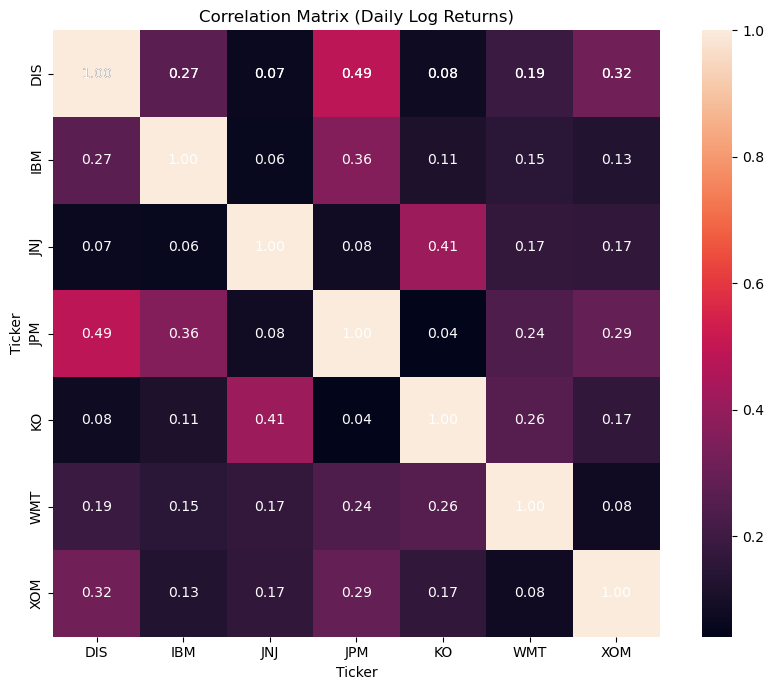

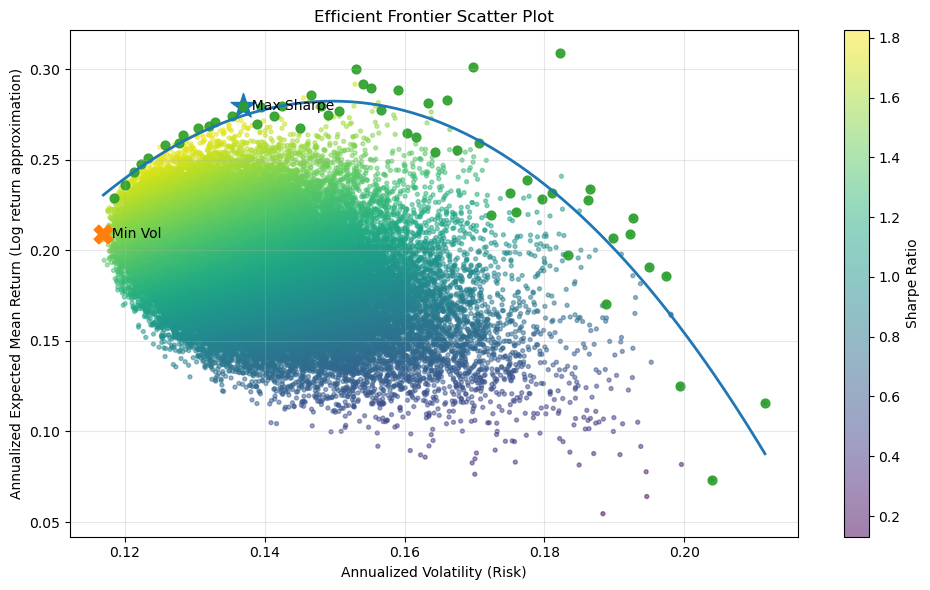

Saved outputs:
 - correlation_matrix_png: efficient_frontier_correlation_matrix.png
 - frontier_png: efficient_frontier_frontier.png
 - optimal_sharpe_weights_csv: efficient_frontier_optimal_sharpe_weights.csv
 - optimal_min_vol_weights_csv: efficient_frontier_optimal_min_vol_weights.csv
 - report_txt: efficient_frontier_report.txt


In [61]:
tickers = ["JPM", "KO", "XOM", "JNJ", "WMT", "DIS", "IBM"]  # 7 NYSE tickers

proj = EfficientFrontierProject(
    tickers=tickers,
    years=2,
    rf_annual=0.03,
    seed=42
)

proj.fetch_prices(price_field="Close")
proj.compute_inputs()
proj.run_monte_carlo(n_portfolios=50_000)  # increase if you want smoother frontier
paths = proj.plot_and_save(out_prefix="efficient_frontier")

print("Saved outputs:")
for k, v in paths.items():
    print(f" - {k}: {v}")